# $\text{Recherche}$
## $\text{Modèle de prédiction des affluences des parkings}$

In [42]:
# Import des librairies
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

import matplotlib.pyplot as plt

### Import / traitement des données

In [43]:
data_file_path = "data/data.csv"

# Chargement des données
data = pd.read_csv(data_file_path)

# Tri par date
data = data.sort_values(by='lastupdate')

# Nettoyage des données
data.dropna(inplace=True)  # Suppression des lignes avec des valeurs manquantes
data.drop_duplicates(inplace=True)  # Suppression des doublons

# Encodage des variables
data['idparc'] = data['idparc'].astype('category').cat.codes # Catégoriser l'id du parc
data['etatouverture'] = data['etatouverture'].map({'OUVERT': 1, 'FERME': 0}) # Encoder l'état d'ouverture

# Créer des colonnes dérivées pour le temps
last_dt = pd.to_datetime(data['lastupdate'])
data['lastupdate_hour_cos'] = np.cos(2 * np.pi * (last_dt.dt.hour + last_dt.dt.minute / 60.0) / 24)
data['lastupdate_hour_sin'] = np.sin(2 * np.pi * (last_dt.dt.hour + last_dt.dt.minute / 60.0) / 24)
data['lastupdate_month'] = last_dt.dt.month  # mois
data['lastupdate_dayofweek'] = last_dt.dt.dayofweek  # jour de la semaine (0= lundi, 6= dimanche)
data.drop('lastupdate', axis=1, inplace=True)

# Transformation de capacitesoliste et jrdinfosoliste en pourcentage d'occupation
data['occupation_rate'] = data['jrdinfosoliste'] / data['capacitesoliste']
capacite_soliste = data['capacitesoliste'].values
data.drop(['capacitesoliste', 'jrdinfosoliste'], axis=1, inplace=True)

print(data.describe())
print(data.head())

              idparc  etatouverture  lastupdate_hour_cos  lastupdate_hour_sin  \
count  150688.000000  150688.000000        150688.000000        150688.000000   
mean        3.500000       0.741187            -0.086971             0.032044   
std         2.291295       0.437984             0.679737             0.727580   
min         0.000000       0.000000            -1.000000            -1.000000   
25%         1.750000       0.000000            -0.754710            -0.737277   
50%         3.500000       1.000000            -0.139173             0.130526   
75%         5.250000       1.000000             0.559193             0.754710   
max         7.000000       1.000000             1.000000             1.000000   

       lastupdate_month  lastupdate_dayofweek  occupation_rate  
count     150688.000000         150688.000000    150688.000000  
mean          10.729189              2.761839         0.433481  
std            0.444380              1.932829         0.365184  
min       

### Statistiques

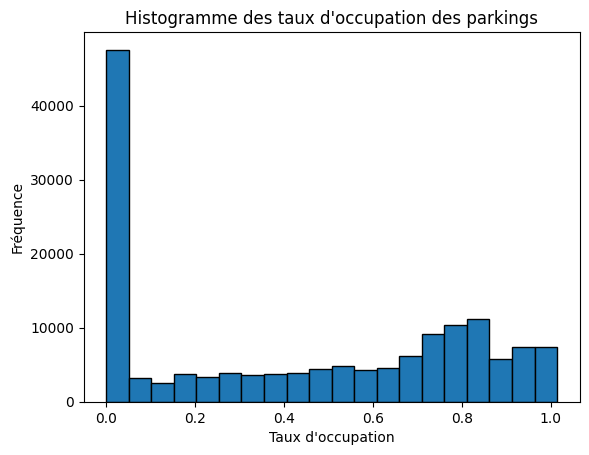

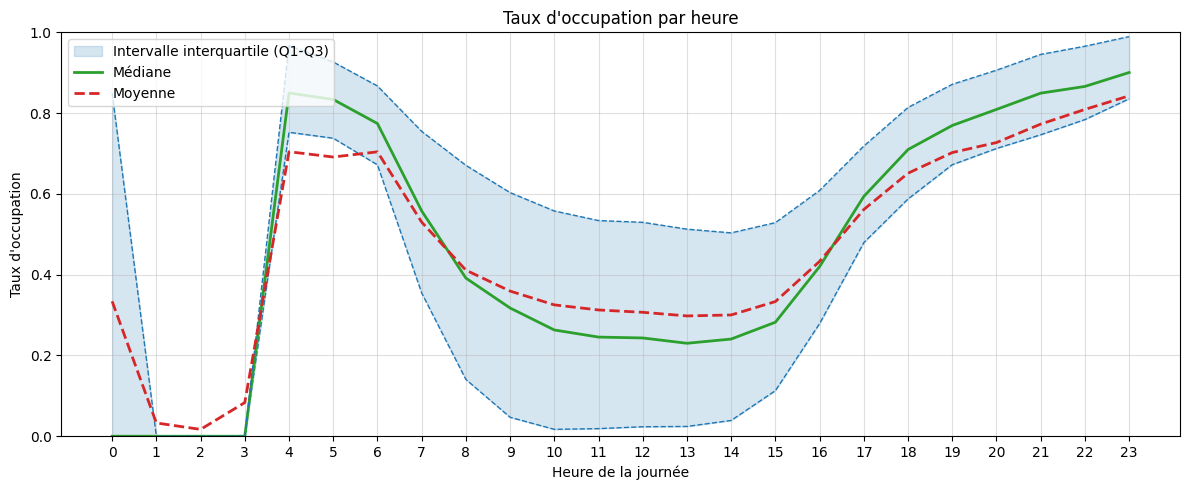

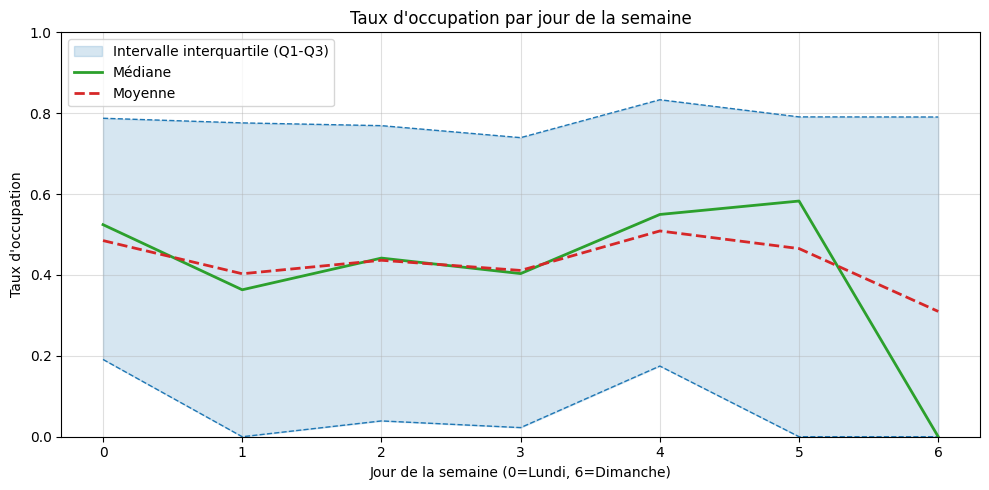

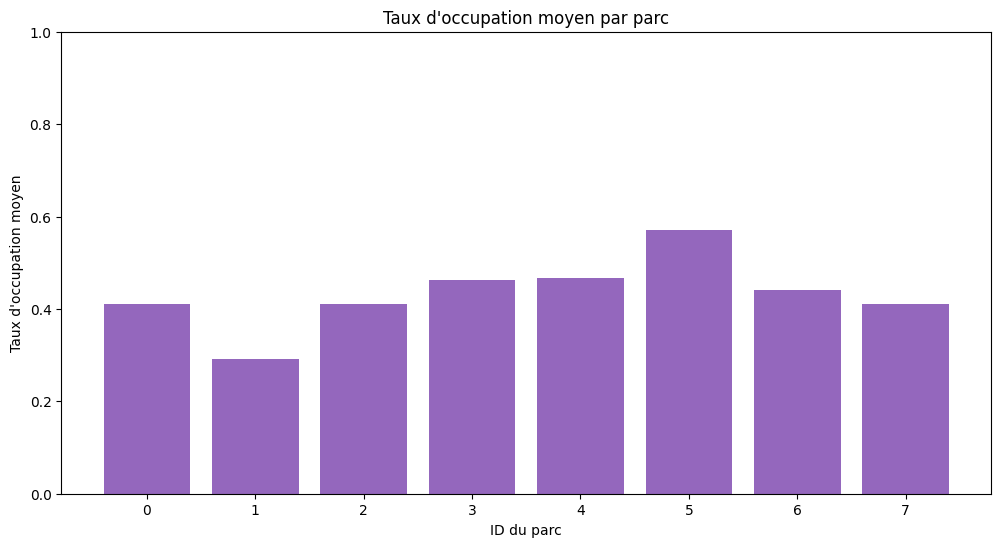

In [44]:
# Histogramme des taux d'occupation
plt.hist(data['occupation_rate'].to_numpy(), bins=20, edgecolor='black')
plt.title('Histogramme des taux d\'occupation des parkings')
plt.xlabel('Taux d\'occupation')
plt.ylabel('Fréquence')
plt.show()

# Taux d'occupation par heure
hour = last_dt.dt.hour  # heure entière (sans modifier `data`)

hourly_q = data.groupby(hour)['occupation_rate'].quantile(np.array([0.25, 0.5, 0.75])).unstack()
mean_by_hour = data.groupby(hour)['occupation_rate'].mean()

x = mean_by_hour.index.to_numpy()
q1 = hourly_q[0.25].to_numpy()
median = hourly_q[0.5].to_numpy()
q3 = hourly_q[0.75].to_numpy()
mean = mean_by_hour.to_numpy()

fig, ax = plt.subplots(figsize=(12, 5))

# Zone IQR (q1 -> q3)
ax.fill_between(x, q1, q3, color='C0', alpha=0.18, label="Intervalle interquartile (Q1-Q3)")

# Tracés des quantiles et de la moyenne
ax.plot(x, q1, linestyle='--', color='C0', linewidth=1)
ax.plot(x, median, linestyle='-', color='C2', linewidth=2, label='Médiane')
ax.plot(x, q3, linestyle='--', color='C0', linewidth=1)
ax.plot(x, mean, linestyle='--', color='C3', linewidth=2, label='Moyenne')

# Mise en forme
ax.set_title("Taux d'occupation par heure")
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Taux d'occupation")
ax.set_ylim(0, 1)
ax.set_xticks(range(0, 24))
ax.grid(alpha=0.4)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Taux d'occupation par jour de la semaine
day_of_week_q = data.groupby('lastupdate_dayofweek')['occupation_rate'].quantile(np.array([0.25, 0.5, 0.75])).unstack()
mean_by_day = data.groupby('lastupdate_dayofweek')['occupation_rate'].mean()

x = mean_by_day.index.to_numpy()
q1 = day_of_week_q[0.25].to_numpy()
median = day_of_week_q[0.5].to_numpy()
q3 = day_of_week_q[0.75].to_numpy()
mean = mean_by_day.to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))

# Zone IQR (q1 -> q3)
ax.fill_between(x, q1, q3, color='C0', alpha=0.18, label="Intervalle interquartile (Q1-Q3)")

# Tracés des quantiles et de la moyenne
ax.plot(x, q1, linestyle='--', color='C0', linewidth=1)
ax.plot(x, median, linestyle='-', color='C2', linewidth=2, label='Médiane')
ax.plot(x, q3, linestyle='--', color='C0', linewidth=1)
ax.plot(x, mean, linestyle='--', color='C3', linewidth=2, label='Moyenne')

# Mise en forme
ax.set_title("Taux d'occupation par jour de la semaine")
ax.set_xlabel("Jour de la semaine (0=Lundi, 6=Dimanche)")
ax.set_ylabel("Taux d'occupation")
ax.set_ylim(0, 1)
ax.set_xticks(range(0, 7))
ax.grid(alpha=0.4)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Taux d'occupation par parc
park_means = data.groupby('idparc')['occupation_rate'].mean()
plt.figure(figsize=(12, 6))
plt.bar(park_means.index.astype(str), park_means, color='C4')
plt.title('Taux d\'occupation moyen par parc')
plt.xlabel('ID du parc')
plt.ylabel('Taux d\'occupation moyen')
plt.ylim(0, 1)
plt.show()

### Séparation des jeux de données

In [45]:
test_size = 0.25

# Les données doivent être triées par date avant le split
split_index = int(len(data) * (1 - test_size))
train_set = data.iloc[:split_index]
test_set = data.iloc[split_index:]

X_train = train_set.drop('occupation_rate', axis=1)
y_train = train_set['occupation_rate']

X_test = test_set.drop('occupation_rate', axis=1)
y_test = test_set['occupation_rate']

### **Régression Linéaire**

In [46]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
# Seuillage des prédictions
predictions = [min(max(0, predictions[i]), capacite_soliste[i]) for i in range(len(predictions))]

y_true = y_test.to_numpy()
y_pred = np.array(predictions)

# Conversion en pourcentage
y_true = y_true*100  
y_pred = y_pred*100

sample = 10
for i in range(sample):
    print(f"Vrai: {y_true[i]:.2f}%, Prédit: {y_pred[i]:.2f}%")

Vrai: 0.00%, Prédit: 0.00%
Vrai: 0.00%, Prédit: 0.00%
Vrai: 0.00%, Prédit: 0.00%
Vrai: 70.27%, Prédit: 51.69%
Vrai: 76.01%, Prédit: 53.02%
Vrai: 0.00%, Prédit: 0.00%
Vrai: 83.44%, Prédit: 52.58%
Vrai: 83.52%, Prédit: 53.25%
Vrai: 83.59%, Prédit: 52.61%
Vrai: 0.00%, Prédit: 0.00%


#### Évaluation

MSE : 455.7933017518585
RMSE : 21.349316189326967
MAE : 15.33451198368825
R² : 0.5453642322396117


C:\Users\theo_\AppData\Local\Temp\ipykernel_37820\1956221265.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = df.groupby("bin")["error"].mean().reset_index()


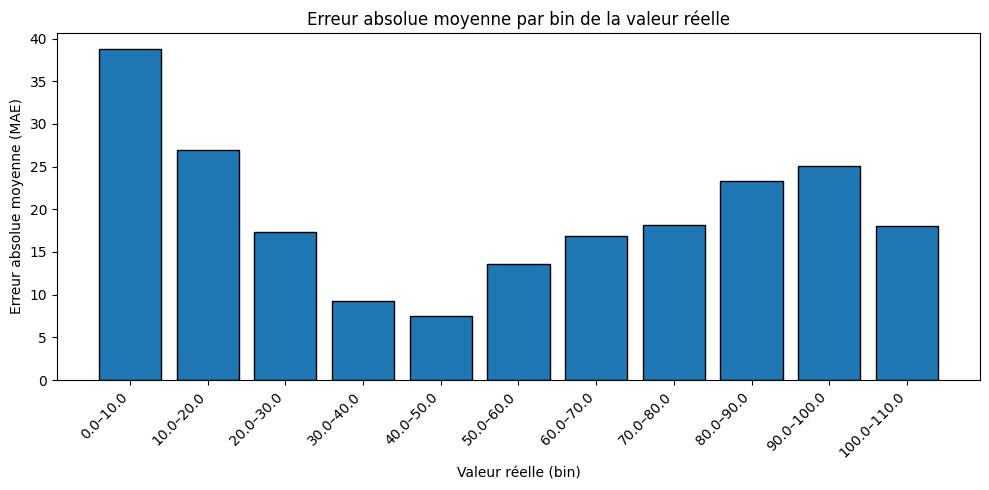

      label     error
   0.0–10.0 38.743657
  10.0–20.0 26.955346
  20.0–30.0 17.389172
  30.0–40.0  9.269978
  40.0–50.0  7.517165
  50.0–60.0 13.551283
  60.0–70.0 16.821741
  70.0–80.0 18.176170
  80.0–90.0 23.263890
 90.0–100.0 25.064073
100.0–110.0 18.064731


In [47]:
# Évaluation du modèle
mse = mean_squared_error(y_true, y_pred)
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))
print("MAE :", sum(abs(y_true[i] - y_pred[i]) for i in range(len(y_pred))) / len(y_pred))
print("R² :", model.score(X_test, y_test))

# Histogramme des erreurs absolues moyennes en fonction de la valeur réelle
errors = np.abs(y_true - y_pred)

bin_width = 10
min_val = np.floor(y_true.min() / bin_width) * bin_width
max_val = np.ceil(y_true.max() / bin_width) * bin_width
bins = np.arange(min_val, max_val + bin_width, bin_width)

# Calcul de la MAE par bin
df = pd.DataFrame({
    "y_true": y_true,
    "error": errors
})
df["bin"] = pd.cut(df["y_true"], bins=bins, right=True)

mae_by_bin = df.groupby("bin")["error"].mean().reset_index()

mae_by_bin["label"] = mae_by_bin["bin"].apply(lambda iv: f"{iv.left:.1f}–{iv.right:.1f}") # labels
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(mae_by_bin["label"], mae_by_bin["error"], width=0.8, color="C0", edgecolor="k")
ax.set_xlabel("Valeur réelle (bin)")
ax.set_ylabel("Erreur absolue moyenne (MAE)")
ax.set_title("Erreur absolue moyenne par bin de la valeur réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Affichage optionnel des valeurs numériques
print(mae_by_bin[["label", "error"]].to_string(index=False))

### **Random Forest**

In [48]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
# Seuillage des prédictions
predictions = [min(max(0, predictions[i]), capacite_soliste[i]) for i in range(len(predictions))]
y_true = y_test.to_numpy()
y_pred = np.array(predictions)
# Conversion en pourcentage
y_true = y_true*100
y_pred = y_pred*100

sample = 10
for i in range(sample):
    print(f"Vrai: {y_true[i]:.2f}%, Prédit: {y_pred[i]:.2f}%")

Vrai: 0.00%, Prédit: 0.00%
Vrai: 0.00%, Prédit: 0.00%
Vrai: 0.00%, Prédit: 0.00%
Vrai: 70.27%, Prédit: 68.48%
Vrai: 76.01%, Prédit: 41.20%
Vrai: 0.00%, Prédit: 0.00%
Vrai: 83.44%, Prédit: 79.72%
Vrai: 83.52%, Prédit: 82.17%
Vrai: 83.59%, Prédit: 79.42%
Vrai: 0.00%, Prédit: 0.00%


#### Évaluation

MSE : 325.87143383328697
RMSE : 18.05190942347338
MAE : 8.488516379855987
R² : 0.7447172686372283


C:\Users\theo_\AppData\Local\Temp\ipykernel_37820\1956221265.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = df.groupby("bin")["error"].mean().reset_index()


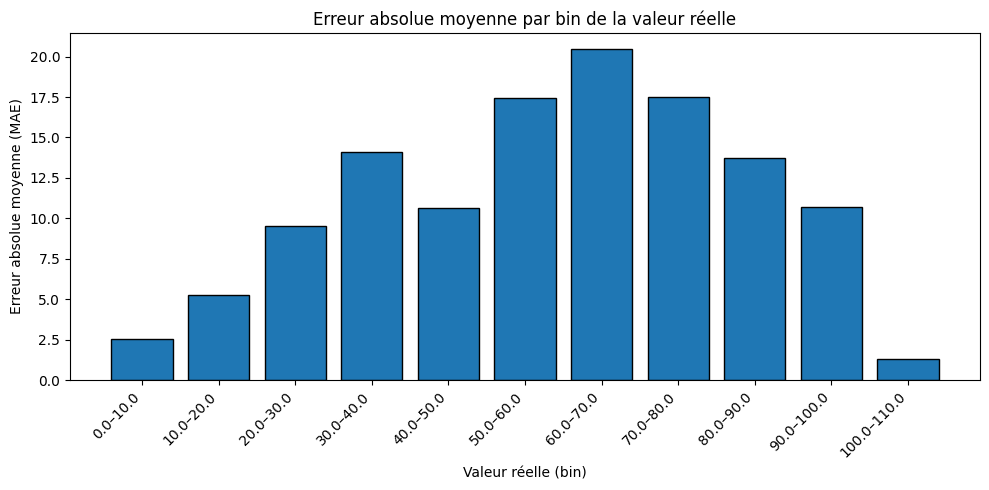

      label     error
   0.0–10.0  2.555679
  10.0–20.0  5.276174
  20.0–30.0  9.519432
  30.0–40.0 14.110712
  40.0–50.0 10.622741
  50.0–60.0 17.420840
  60.0–70.0 20.449200
  70.0–80.0 17.524471
  80.0–90.0 13.748519
 90.0–100.0 10.684991
100.0–110.0  1.313109


In [49]:
# Évaluation du modèle
mse = mean_squared_error(y_true, y_pred)
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))
print("MAE :", sum(abs(y_true[i] - y_pred[i]) for i in range(len(y_pred))) / len(y_pred))
print("R² :", model.score(X_test, y_test))

# Histogramme des erreurs absolues moyennes en fonction de la valeur réelle
errors = np.abs(y_true - y_pred)

bin_width = 10
min_val = np.floor(y_true.min() / bin_width) * bin_width
max_val = np.ceil(y_true.max() / bin_width) * bin_width
bins = np.arange(min_val, max_val + bin_width, bin_width)

# Calcul de la MAE par bin
df = pd.DataFrame({
    "y_true": y_true,
    "error": errors
})
df["bin"] = pd.cut(df["y_true"], bins=bins, right=True)

mae_by_bin = df.groupby("bin")["error"].mean().reset_index()

mae_by_bin["label"] = mae_by_bin["bin"].apply(lambda iv: f"{iv.left:.1f}–{iv.right:.1f}") # labels
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(mae_by_bin["label"], mae_by_bin["error"], width=0.8, color="C0", edgecolor="k")
ax.set_xlabel("Valeur réelle (bin)")
ax.set_ylabel("Erreur absolue moyenne (MAE)")
ax.set_title("Erreur absolue moyenne par bin de la valeur réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Affichage optionnel des valeurs numériques
print(mae_by_bin[["label", "error"]].to_string(index=False))

### **Gradient Boosting**

In [50]:
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
# Seuillage des prédictions
predictions = [min(max(0, predictions[i]), capacite_soliste[i]) for i in range(len(predictions))]
y_true = y_test.to_numpy()
y_pred = np.array(predictions)
# Conversion en pourcentage
y_true = y_true*100
y_pred = y_pred*100

### Évaluation

In [51]:
# Évaluation du modèle
mse = mean_squared_error(y_true, y_pred)
print(f"MSE : {mse}")
print("RMSE :", np.sqrt(mse))
print("MAE :", sum(abs(y_true[i] - y_pred[i]) for i in range(len(y_pred))) / len(y_pred))
print("R² :", model.score(X_test, y_test))

MSE : 275.31327285969957
RMSE : 16.592566795396653
MAE : 9.703678654650842
R² : 0.7804533920514181
